In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

In [2]:
start = '2010-01-01'
end = '2025-12-01'


In [3]:
# pip install --upgrade yfinance certifi urllib3

In [4]:
data = yf.download('AAPL',start,end)

[*********************100%***********************]  1 of 1 completed


In [5]:
data.shape

(4002, 5)

In [6]:
data.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2010-01-04,6.412383,6.427064,6.363543,6.395004,493729600
2010-01-05,6.423469,6.459724,6.389610,6.430061,601904800
2010-01-06,6.321296,6.448938,6.314704,6.423470,552160000
2010-01-07,6.309611,6.352159,6.263768,6.344668,477131200
2010-01-08,6.351558,6.352158,6.264067,6.301220,447610800


In [7]:
data  = data.reset_index()

In [8]:
data.head()

Price,Date,Close,High,Low,Open,Volume
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL
0,2010-01-04,6.412383,6.427064,6.363543,6.395004,493729600
1,2010-01-05,6.423469,6.459724,6.389610,6.430061,601904800
2,2010-01-06,6.321296,6.448938,6.314704,6.423470,552160000
3,2010-01-07,6.309611,6.352159,6.263768,6.344668,477131200
4,2010-01-08,6.351558,6.352158,6.264067,6.301220,447610800


In [9]:
# data = data.drop(columns = ["Date"],axis=1)

In [10]:
data.head()

Price,Date,Close,High,Low,Open,Volume
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL
0,2010-01-04,6.412383,6.427064,6.363543,6.395004,493729600
1,2010-01-05,6.423469,6.459724,6.389610,6.430061,601904800
2,2010-01-06,6.321296,6.448938,6.314704,6.423470,552160000
3,2010-01-07,6.309611,6.352159,6.263768,6.344668,477131200
4,2010-01-08,6.351558,6.352158,6.264067,6.301220,447610800


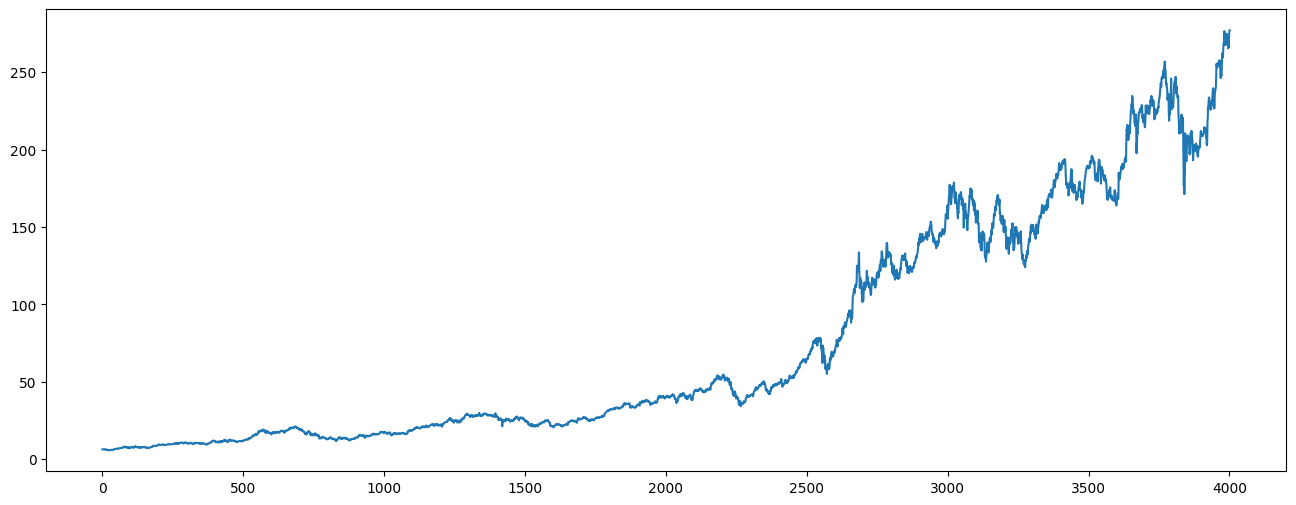

In [11]:
# ploting the Open
plt.figure(figsize=(16,6))
plt.plot(data.Open)
plt.show()

In [12]:
MA100_open = data.Open.rolling(100).mean()
MA200_open = data.Open.rolling(200).mean()

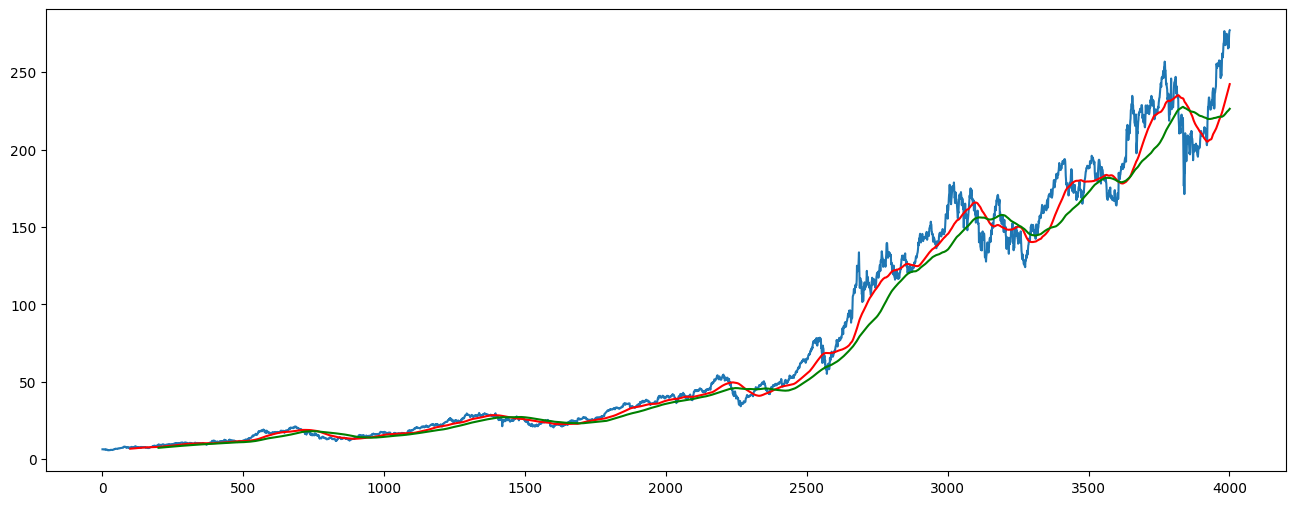

In [13]:
plt.figure(figsize=(16,6))
plt.plot(data.Open)
plt.plot(MA100_open,'r')
plt.plot(MA200_open,'g')
plt.show()

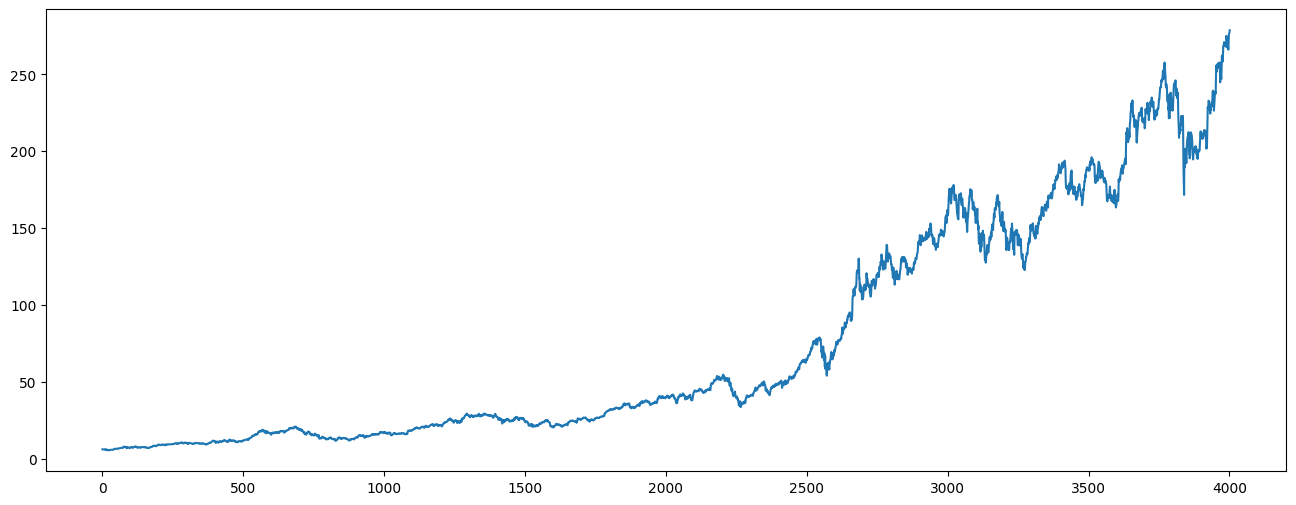

In [14]:
# Now Lets Plot The Closeing Value
plt.figure(figsize=(16,6))
plt.plot(data.Close)
plt.show()


In [15]:
MA100_close = data.Close.rolling(100).mean()
MA200_close = data.Close.rolling(200).mean()

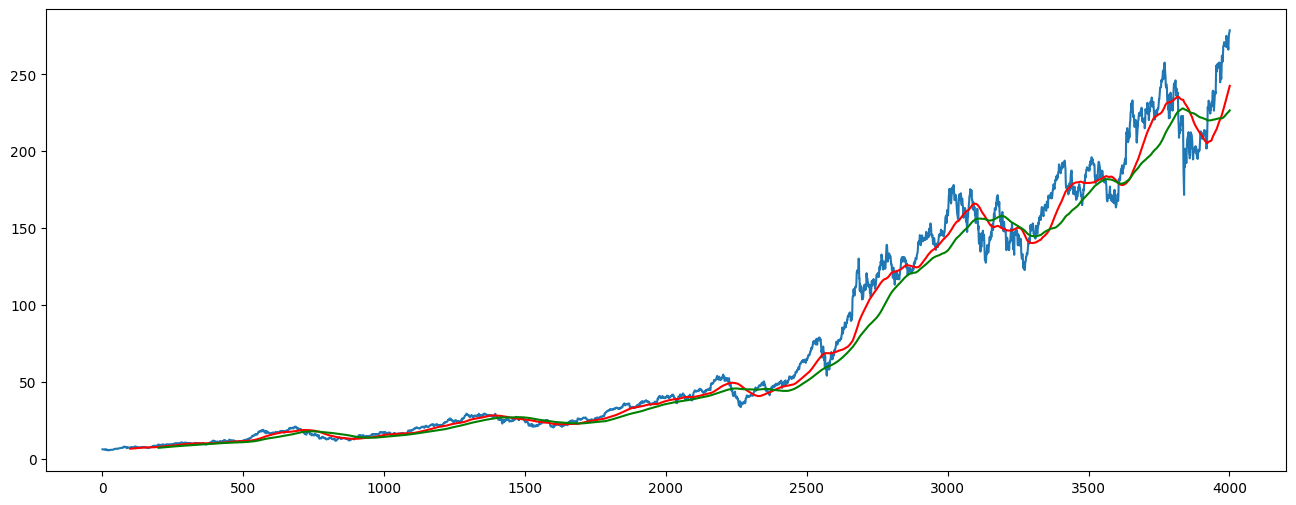

In [16]:
plt.figure(figsize=(16,6))
plt.plot(data.Close)
plt.plot(MA100_close,'r')
plt.plot(MA200_close,'g')
plt.show()

In [17]:
# now lets split the data , here we have in the dataframe so we have to split with the pandas not sklearn
# For open
Opndata_training = pd.DataFrame(data['Open'][0:int(len(data)*0.70)])
Opndata_testing= pd.DataFrame(data['Open'][int(len(data)*0.70):int(len(data))])
print("For 'Open' column")
print(f"The shape of Training is : {Opndata_training.shape}")
print(f"The shape of Testing is : {Opndata_testing.shape}")

For 'Open' column
The shape of Training is : (2801, 1)
The shape of Testing is : (1201, 1)


In [18]:
# now lets split the data for Close
Cls_data_training = pd.DataFrame(data["Close"][0:int(len(data)*0.70)])
Cls_data_testing = pd.DataFrame(data["Close"][int(len(data)*0.70):int(len(data))])

print("For 'Close' column")
print(f"The shape of Training is : {Cls_data_training.shape}")
print(f"The shape of Testing is : {Cls_data_testing.shape}")


For 'Close' column
The shape of Training is : (2801, 1)
The shape of Testing is : (1201, 1)


In [19]:
from sklearn.preprocessing import MinMaxScaler

In [20]:
Scaler = MinMaxScaler(feature_range=(0,1))

In [21]:
Opndata_training_array = Scaler.fit_transform(Opndata_training)
Opndata_training_array

array([[0.00471287],
       [0.0049747 ],
       [0.00492547],
       ...,
       [0.94256335],
       [0.91171962],
       [0.8968071 ]])

In [22]:
# now lets make X_train,y_train to make ML model
# AMA pachal na 150 divas ni value learn karine model 151 ma divas ni price pred karse , 152 ma divse 1lo di list mathi nikli jashe and 151 append evi rite loop halse end sudhi 
X_train = []
y_train = []

for i in range(150,Opndata_training_array.shape[0]):
    X_train.append(Opndata_training_array[i-150:i])
    y_train.append(Opndata_training_array[i,0])

# now lets convert this into a numpy array
X_train,y_train = np.array(X_train),np.array(y_train)


In [23]:
# now lets building the ml model on this training data or "Opening" of the Stock
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense,Dropout,LSTM
import warnings
warnings.filterwarnings("ignore")

In [53]:
model = Sequential()
model.add(LSTM(units = 50,activation='relu', return_sequences=True,input_shape = (X_train.shape[1],1)))
model.add(Dropout(0.2))

model.add(LSTM(units = 60,activation='relu', return_sequences=True))
model.add(Dropout(0.3))

model.add(LSTM(units = 80,activation='relu', return_sequences=True))
model.add(Dropout(0.4))


In [54]:
model.add(Dense(units=1))

In [55]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                        │ (None, 150, 50)             │          10,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 150, 50)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_5 (LSTM)                        │ (None, 150, 60)             │          26,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 150, 60)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_6 (LSTM)                        │ (None, 150, 80)             │          45,120 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 150, 80)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 150, 1)              │              81 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 82,241 (321.25 KB)

 Trainable params: 82,241 (321.25 KB)

 Non-trainable params: 0 (0.00 B)

In [56]:
model.compile(optimizer='adam',loss='mean_squared_error',metrics=['accuracy'])
history = model.fit(X_train,y_train,epochs =20,validation_split = 0.2)

Epoch 1/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 37s 377ms/step - accuracy: 0.0000e+00 - loss: 0.0085 - val_accuracy: 0.0000e+00 - val_loss: 0.1890
Epoch 2/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 38s 326ms/step - accuracy: 0.0000e+00 - loss: 0.0072 - val_accuracy: 0.0000e+00 - val_loss: 0.1935
Epoch 3/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 21s 307ms/step - accuracy: 0.0000e+00 - loss: 0.0071 - val_accuracy: 0.0000e+00 - val_loss: 0.1876
Epoch 4/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 21s 307ms/step - accuracy: 0.0000e+00 - loss: 0.0070 - val_accuracy: 0.0000e+00 - val_loss: 0.1900
Epoch 5/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 20s 299ms/step - accuracy: 0.0000e+00 - loss: 0.0070 - val_accuracy: 0.0000e+00 - val_loss: 0.1941
Epoch 6/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 21s 317ms/step - accuracy: 0.0000e+00 - loss: 0.0070 - val_accuracy: 0.0000e+00 - val_loss: 0.1982
Epoch 7/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 22s 321ms/step - accuracy: 0.0000e+00 - loss: 0.0070 - val_accuracy: 0.0000e+00 - val_loss: 0.1883
Epoch 8/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 22s

In [31]:
model.save('keras_model.h5')

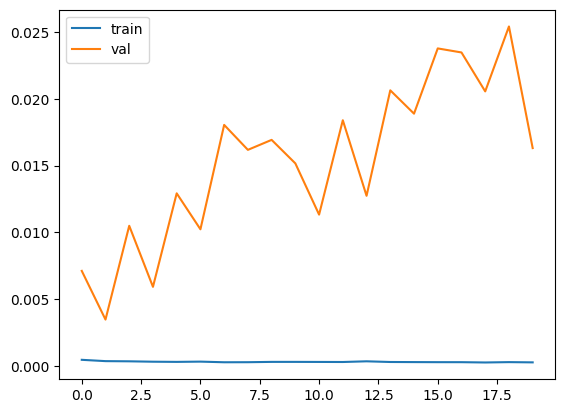

In [32]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.legend()

In [35]:
Opndata_testing.head()

Ticker,AAPL
2801,126.853194
2802,124.681168
2803,120.541693
2804,121.691005
2805,121.437765


In [36]:
past100Days = Opndata_training.tail(100)
past100Days

Ticker,AAPL
2701,105.271142
2702,111.659440
2703,111.212841
2704,110.474986
2705,114.212824
...,...
2796,132.365963
2797,130.856328
2798,131.966664
2799,127.836903


In [37]:
final_data = pd.concat([past100Days,Opndata_testing],ignore_index=True) #aaya False karwa thi sachi index mali jai 

In [38]:
final_data.head()

Ticker,AAPL
0,105.271142
1,111.659440
2,111.212841
3,110.474986
4,114.212824


In [39]:
final_data.tail()

Ticker,AAPL
1296,265.701377
1297,270.646752
1298,275.012667
1299,276.701083
1300,277.000815


In [40]:
input_data = Scaler.transform(final_data)
input_data

array([[0.74318391],
       [0.79089585],
       [0.78756036],
       ...,
       [2.01092355],
       [2.02353373],
       [2.02577232]])

In [41]:
input_data.shape

(1301, 1)

In [42]:
X_test = []
y_test = []

for i in range(150,input_data.shape[0]):
    X_test.append(input_data[i-150:i])
    y_test.append(input_data[i,0])

X_test,y_test = np.array(X_test),np.array(y_test)
print(X_test.shape)
print(y_test.shape)


(1151, 150, 1)
(1151,)


In [43]:
# making predictions
y_predicted = model.predict(X_test)

36/36 ━━━━━━━━━━━━━━━━━━━━ 9s 217ms/step


In [44]:
y_predicted.shape

(1151, 1)

In [45]:
y_test

array([0.91746674, 0.91128327, 0.89680707, ..., 2.01092355, 2.02353373,
       2.02577232])

In [46]:
y_predicted

array([[0.6405927],
       [0.6393293],
       [0.637729 ],
       ...,
       [0.6688594],
       [0.6658447],
       [0.6647567]], dtype=float32)

In [47]:
factor = Scaler.scale_
factor

array([0.00746865])

In [48]:
# scaled_factor = 1/factor
# y_predicted = y_predicted * scaled_factor
# y_test = y_test * scaled_factor
y_predicted = Scaler.inverse_transform(y_predicted.reshape(-1,1))
y_test = Scaler.inverse_transform(y_test.reshape(-1,1))

In [49]:
y_test

array([[128.60640114],
       [127.77847859],
       [125.84021548],
       ...,
       [275.01266705],
       [276.70108255],
       [277.00081501]])

In [50]:
y_predicted

array([[91.53489 ],
       [91.36573 ],
       [91.15146 ],
       ...,
       [95.31961 ],
       [94.915955],
       [94.77029 ]], dtype=float32)

In [51]:
print(y_predicted.shape)
print(y_test.shape)

(1151, 1)
(1151, 1)


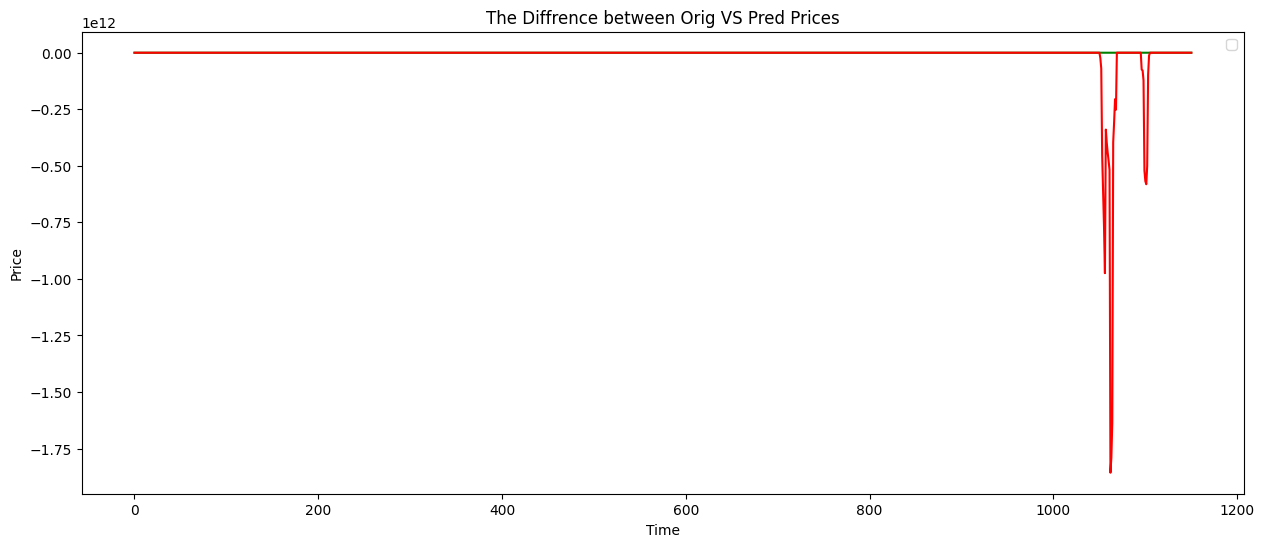

In [52]:
plt.figure(figsize=(15,6))
plt.plot(y_test,'g',label="Original Price")
plt.plot(y_predicted,'r',label="Predicted Price")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend("")
plt.title("The Diffrence between Orig VS Pred Prices")
plt.show()